<h1> German Articles Classifier </h1>
<p> In german language there are 3 types of articles (der - masculine, die - feminine, das - neutral)</p>
<p> Each noun has its article (it may seem strange, because in english there is no such thing)</p>
<p> On of the hardest aspects of learning german is remembering the articles, there are some patterns for it, but it is not that simple, in this project I will show whether a neural network can can classify the article of the noun by </p>
<p>- semantic meaning</p>
<p>- letters of the words</p>
<p>before starting, if you know german, how accurate do you think these models can get?</p> 

first the semantic meaning approach, we will download an embedding matrix (it contains a vector for each word corresponding to its meaning) from fasttext libary. It is trained on the german wikipedia

In [ ]:
import fasttext
import fasttext.util
import os

if os.path.exists('cc.de.300.bin'):
    ft = fasttext.load_model('cc.de.300.bin')
else: 
    fasttext.util.download_model('de', if_exists='ignore')
    ft = fasttext.load_model('cc.de.300.bin')
ft.get_dimension()

In [ ]:
print("total words:", len(ft.get_words()))

In [ ]:
ft.get_words()[10000:10020]

as we see, there are 2 mln words here. This is much more than in dictionaries because it also count specific dates, missspelled words etc. Lets see some synonyms of a word 'Kaiser'

In [ ]:
synonym = ft.get_nearest_neighbors("Kaiser", k=3)
print(synonym)

We can also see the similarity of the 2 chosen words with some linear algebra

In [ ]:
import numpy as np

def get_similarity(word1, word2, model):
  
    vec1 = model.get_word_vector(word1)
    vec2 = model.get_word_vector(word2)
    
    
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    
    similarity = dot_product / (norm_vec1 * norm_vec2)
    return similarity

score = get_similarity("Kaiser", "König", ft)
print(f"Similarity score between words: {score:.4f}")



Let's create another table with the words and their articles

In [ ]:
import pandas as pd

In [ ]:
nomen = pd.read_csv("mit_artikeln.csv")
nomen = nomen.rename(columns={"ihm": "Nomen", "none": "Artikel"})
nomen.head()

In [ ]:
nomen.shape

we have to drop all the words which are not nouns, we see that most of the words have feminine article. It is correct with the german language. We have to make the words start with a capital letter (german quirk).

In [ ]:
nomen = nomen[nomen['Artikel'] != "none"]
nomen.value_counts("Artikel")

In [ ]:
nomen['Nomen'] = nomen['Nomen'].str.capitalize()
nomen.head()
nomen.dropna(inplace=True)

now we have our table with articles prepared, let's get only those embeddings where the word in our table exists

In [ ]:
embeddings = []
for wort in nomen['Nomen']:
    vec = ft.get_word_vector(wort)
    embeddings.append(vec)

In [ ]:
print(len(embeddings))
print(len(nomen))

In [ ]:
N = len(nomen)

In [ ]:
embeddings[0]

In [ ]:
nomen[2000:2005]


 we might not have to shuffle the data because the words that come first are the ones that are easier to learn (more people know the). This will simulate a learning person better

In [ ]:
X = np.array(embeddings, dtype='float32')
y = nomen['Artikel'].values

In [ ]:
mapping = {'f': 2, 'm': 1, 'n': 0}
y = np.array([mapping[artikel] for artikel in y])

In [ ]:
y

great, now we can add train, test and valid sets. As we previously told, we do not shuffle them

In [ ]:
X_train = X[:10000]
y_train = y[:10000]
X_valid = X[10000:15000]
y_valid = y[10000:15000]
X_test = X[15000:]
y_test = y[15000:]


In [ ]:
import tensorflow as tf

In [ ]:
print("y_train type:", type(y_train[0]))    # Should be an int or float

we are ready to prepare our model, we will use tensorflow

In [ ]:
artikel_guesser = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(300,)),
    tf.keras.layers.Dense(256, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3, activation="softmax")
])

optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights=True
)
artikel_guesser.compile(optimizer=optimizer,
                        loss = 'sparse_categorical_crossentropy',
                        metrics = ['accuracy'])
artikel_guesser.summary()

    


In [ ]:
history = artikel_guesser.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), callbacks=[early_stop])

In [ ]:
artikel_guesser.evaluate(X_test, y_test)

our accuracy is about 95%, this is far better than I expected. It might suggest that most of articles in german make sense

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = artikel_guesser.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['n', 'm', 'f'])
disp.plot(cmap=plt.cm.Blues)

In [ ]:
reverse_mapping = {0 : 'Neutrum', 1 : 'Maskulinum', 2 : 'Femininum'}
dmapping = {0 : 'das', 1 : 'der', 2 : 'die'}
dmapping2 = {'n' : 'das', 'm' : 'der', 'f' : 'die'}

you can now see some words and which articles are predicted for them

In [ ]:
def give_artikel(wort, model=artikel_guesser,mapping=dmapping,):
    wort_vec = np.array(ft.get_word_vector(wort), dtype='float32')
    wort_vec = wort_vec.reshape(1,-1)
    probas = model.predict(wort_vec)
    print(str(mapping[np.argmax(probas)]) + " " + wort)

def give_artikel_return(wort, model=artikel_guesser,mapping=dmapping,):
    wort_vec = np.array(ft.get_word_vector(wort), dtype='float32')
    wort_vec = wort_vec.reshape(1,-1)
    probas = model.predict(wort_vec)
    return str(mapping[np.argmax(probas)])
    

In [ ]:
give_artikel('Katze') #write the word you want to test here

In [ ]:
nomen.loc[nomen['Nomen'] == 'Katze']['Artikel'].iloc[0] 
# additional code, for future pandas use :)
#it is like SELECT * FROM nomen WHERE Nomen == 'Katze'

In [ ]:
def true_artikel(wort, nomen=nomen, mapping=dmapping2):
    art = nomen.loc[nomen['Nomen'] == wort]['Artikel'].iloc[0]
    d = mapping[art]
    print(d + " " + wort)

def true_artikel_return(wort, nomen=nomen, mapping=dmapping2):
    art = nomen.loc[nomen['Nomen'] == wort]['Artikel'].iloc[0]
    d = mapping[art]
    return d

In [ ]:
true_artikel('Katze') #this function gives the correct article with a clean output 

here are some random 50 words to be evaluated

In [ ]:
zahl = 50
worter = nomen['Nomen'].sample(zahl)
worter = worter.values
worter

In [ ]:
def Ergebnis(worter): # function to test the model with multiple words
    for w in worter:
        print("vorausgesagt Ergebnis: ")
        give_artikel(w)
        print("richtige Ergebnis:")
        true_artikel(w)
        print()
        
        

In [ ]:
Ergebnis(worter)

# Now we will make predictions based on letter permutation

but this is a multi layer perceptron model, we need the same number of inputs every time, and we need to change the letter into some numbers for our model to work, how to do it?

We will take a fixed number of letters (there is a constant named MAXLEN and this is exactly how many we are going to take). But why? In german there are words with 3 letters and 33 letters. Yes but
- we can fill the rest of the short words with zeros (so the computer reads 'Katze00000' instead of 'Katze'), like a zero padding in CNNs
- we can cut the ending of the words so that only the last 10 characters matters for example for the word 'Geschwindigkeibeschränkung' (velocity limit) we will take only 'schränkung' in this case this is a completely different word, but both of these have an article 'die' so it does not matter.

Also the last characters matters most so we will actually have to reverse the words to get a more accurate score. For example words with endings 'ung' or 'keit' have almost always 'die'. But we are not comparing a sequence here so we need the endings of the words at static place. So that the last letter (which matters the most) is actually the first place for a computer to reed

In [ ]:
MAXLEN = 10

categories = ['a',  'b'	,'c',	'd',	'e',	'f',	'g',	'h'	,   'i',	'j',	'k',	'l',	'm',
              	'n',	'o',	'p',	'q',	'r',	's',	't',	'u',	'v',	'w',
                    	'x',	'y',	'z'	,'ä'	,'ö'	,'ü',	'ß', '0']
def word_prep(w, MAXLEN):
    w = w.lower()
    r = []
    n = min(len(w), MAXLEN)
    for i in range(-1, -n-1,-1):
        r.append(w[i])
    if(n < MAXLEN):
        for i in range(MAXLEN-n):
            r.append('0')
    return r

def onehot(cat):
    n = len(cat)
    oh = []
    for i in range(n):
        vec = [0] * n
        vec[i] = 1
        oh.append(vec)
    oh.append([0]*n)
    return oh

OneHot = onehot(categories)
hot_mapping = dict(zip(categories, OneHot))

our letters are actually nominal variables, so we need to encode them in a one-hot way 
I decided to make a one hot 'embedding' matrix manually, because why not!
for example a is [1, 0, 0....] b is [0, 1, 0, 0, ..., 0] etc
oh and '0' (the padding) has a vector of all zeros

In [ ]:
def hotX(w,MAXLEN):
    r = word_prep(w,MAXLEN)
    HX = [hot_mapping[letter] for letter in r]
    flatHX = [item for sublist in HX for item in sublist] #flatten the list of lists into a vector
    return np.array(flatHX, dtype='int8')

In [ ]:
X2 = nomen['Nomen'].values
X2 = [hotX(w, MAXLEN) for w in X2]
X2 = np.stack(X2)

In [ ]:
X2.shape
X2_train = X2[:10000]
X2_valid= X2[10000:15000]
X2_test = X2[15000:]

now our data is ready, the inputs are vectors with a length of 310, because there are 30 letters in german alphabet and we also need a one hot vector for 0 (short words padding)

In [ ]:
artikel_guesser2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(310,)),
    tf.keras.layers.Dense(256, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3, activation="softmax")
])

optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights=True
)
artikel_guesser2.compile(optimizer=optimizer,
                        loss = 'sparse_categorical_crossentropy',
                        metrics = ['accuracy'])
artikel_guesser2.summary()

In [ ]:
historyL = artikel_guesser2.fit(X2_train, y_train, epochs=100, validation_data=(X2_valid, y_valid), callbacks=[early_stop])

In [ ]:
artikel_guesser2.evaluate(X2_test, y_test)

we get 80%, that is quite what I expected. it is worse than the score from the first guesser, however the values of an embedding matrix might be a bit correlated with the article of the noun, so the conclusions from the second test are much more reliable. 

In [ ]:
def give_artikel2_return(wort, model=artikel_guesser2,mapping=dmapping,):
    wort_vec = hotX(wort, MAXLEN).reshape(1,-1)
    probas = model.predict(wort_vec)
    return str(mapping[np.argmax(probas)])

def give_artikel2(wort, model=artikel_guesser2,mapping=dmapping,):
    wort_vec = hotX(wort, MAXLEN).reshape(1,-1)
    probas = model.predict(wort_vec)
    print(str(mapping[np.argmax(probas)]) + " " + wort)

def Ergebnis2(worter):
    for w in worter:
        print("vorausgesagt Ergebnis: ")
        give_artikel2(w, model=artikel_guesser2)
        print("richtige Ergebnis:")
        true_artikel(w)
        print()

In [ ]:
zahl = 50
worter = nomen['Nomen'].sample(zahl)
worter = worter.values
Ergebnis2(worter)

In [ ]:
Ergebnis2(['Sonne']) 
# here you can try a second Model, 
#remember about capital Letters in Nouns!

In [ ]:
print(give_artikel2_return('Joghurt'))#here are only predictions, you can try some non existing words

here are some roles for articles in german
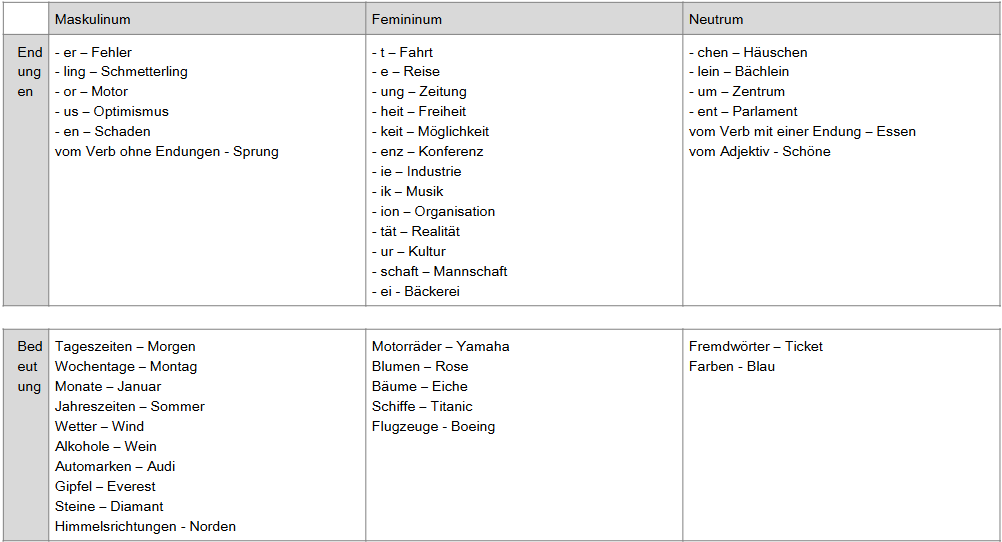

In [ ]:
def give_probas(wort, model=artikel_guesser2,mapping=dmapping,):
    wort_vec = hotX(wort, MAXLEN).reshape(1,-1)
    probas = model.predict(wort_vec)
    print (f'proba for die, [{mapping[2]}]: {probas[0][2] * 100:.1f}%')
    print (f'proba for der, [{mapping[1]}]: {probas[0][1] * 100:.1f}%')
    print (f'proba for das, [{mapping[0]}]: {probas[0][0] * 100:.1f}%')

let's try some rules!

In [ ]:
give_probas('ung')

this is weird, what will happen if the word will get longer

In [ ]:
give_probas('SIGMAung')

In [ ]:
give_probas('chen')

In [ ]:
give_probas('SIGMAchen')

In [ ]:
give_probas('um')

In [ ]:
give_probas('umumumumum')

In [ ]:
give_probas('Schmetterling')

In [ ]:
give_probas('ling')

interesting, the characteristical endings itself does not give accurate results, but when the word is longer the rule is satisfied (it can even make no sense). Schmetterling is an exception.